# Analisis Komparatif: Segmentasi Nasabah Ditolak (Rejected Loans)

Sebagai pelengkap dari analisis profil nasabah utama, dilakukan juga analisis *clustering* pada dataset nasabah yang pengajuan pinjamannya ditolak. Analisis ini bertujuan untuk menemukan persona peminjam "berisiko tinggi yang tidak memenuhi syarat" (*Anti-Persona*), sehingga dapat memberikan wawasan mengenai karakteristik pengajuan yang secara sistematis ditolak oleh institusi.

Dataset ini merupakan data berskala masif (mencapai lebih dari 27,4 juta baris). Oleh karena itu, pendekatan *clustering* difokuskan pada tiga indikator finansial utama yang bersifat numerik: *Amount Requested* (Nominal Pinjaman), *Debt-To-Income Ratio* (Rasio Utang), dan *Employment Length* (Lama Bekerja).

## 1. Load Data
Dataset ini terdiri dari 8 fitur yang telah dibersihkan dan siap untuk dianalisis. Record lebih dari 27,4 juta baris, sehingga proses analisis yang dilakukan akan berbeda dengan data sebelumnya (berbeda dengan accepted).


In [1]:
# %pip install plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans, KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

In [3]:

# df_rej = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Mining Project/Clustering/clean_rejected_loans.csv')
df_rej = pd.read_csv('../Datasets/Cleaning/Phase 2/clean_rejected_loans.csv')

In [4]:
df_rej.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27490787 entries, 0 to 27490786
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Amount Requested      float64
 1   Application Date      object 
 2   Loan Title            object 
 3   Debt-To-Income Ratio  float64
 4   Zip Code              object 
 5   State                 object 
 6   Employment Length     float64
 7   Policy Code           float64
dtypes: float64(4), object(4)
memory usage: 1.6+ GB


In [5]:
df_rej.head()

,Amount Requested,Application Date,Loan Title,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,-0.813023,2007-05-26,Wedding Covered but No Honeymoon,-0.408047,481xx,NM,1.706126,0.0
1,-0.813023,2007-05-26,Consolidating Debt,-0.408047,010xx,MA,-0.356491,0.0
2,-0.141332,2007-05-27,Want to consolidate my debt,-0.408047,212xx,MD,0.159163,0.0
3,-0.477178,2007-05-27,waksman,0.097837,017xx,MA,-0.356491,0.0
4,-0.779439,2007-05-27,mdrigo,-0.418115,209xx,MD,-0.356491,0.0


### Justifikasi Reduksi Fitur (Feature Exclusion) pada Dataset Rejected Loans

Dari total 8 fitur awal yang tersedia pada dataset *Rejected Loans*, proses *clustering* hanya akan menggunakan 3 fitur numerik utama (Amount Requested, Debt-To-Income Ratio, dan Employment Length). Lima fitur lainnya dikecualikan dari pemodelan K-Means berdasarkan tiga justifikasi analitis dan matematis berikut:

1. High Cardinality & Kutukan Dimensi (Fitur: State dan Zip Code)
Meskipun lokasi geografis memiliki nilai bisnis yang tinggi, fitur State (50 kategori) dan Zip Code (puluhan ribu kategori) memiliki tingkat kardinalitas (cardinality) yang ekstrem. Mengubah fitur kategorikal ini menjadi format numerik yang dapat diproses K-Means mengharuskan penggunaan One-Hot Encoding. Hal ini akan menciptakan ribuan kolom baru yang sangat sparse (berisi banyak angka 0). Dalam ruang berdimensi sangat tinggi, perhitungan jarak metrik (Euclidean distance) kehilangan maknanya, yang disebut sebagai Curse of Dimensionality. Selain itu, komputasi ribuan dimensi pada 27,4 juta baris akan melampaui kapasitas fisik memori komputasi.

2. Ketidakcocokan Tipe Data Tekstual (Fitur: Loan Title dan Application Date)
Algoritma K-Means secara murni mengukur jarak jarak geometris antar titik data numerik. Fitur Loan Title berisi teks bebas (free-text) yang diinput manual oleh nasabah (misalnya: "Wedding Covered"). Memproses data ini membutuhkan teknik Natural Language Processing (NLP) yang berada di luar cakupan fase segmentasi numerik. Sementara itu, Application Date (tanggal) merupakan data time-series yang tidak relevan secara geometris untuk pembentukan profil perilaku finansial statis tanpa rekayasa fitur (feature engineering) lebih lanjut.

3. Zero Variance / Redundansi Informasi (Fitur: Policy Code)
Fitur Policy Code pada dataset Rejected Loans umumnya memiliki nilai yang sepenuhnya homogen (statis di angka 0 untuk penolakan). Dalam Data Mining, variabel yang tidak memiliki variansi (zero variance) tidak memberikan nilai informasi apapun kepada algoritma untuk membedakan satu kelompok nasabah dari kelompok lainnya, sehingga fitur ini secara logis harus didrop untuk menjaga efisiensi model.

Kesimpulan Reduksi:
Dengan membuang fitur-fitur yang tidak relevan secara komputasi maupun matematis, algoritma MiniBatchKMeans dapat beroperasi secara eksklusif pada variabel-variabel finansial murni. Hal ini memastikan bahwa segmen yang terbentuk didasarkan pada perilaku risiko dan kapasitas ekonomi, bukan distorsi matematis dari teks atau lokasi.

In [6]:
# Fitur numerik untuk clustering. Ketiga fitur INI SUDAH dinormalisasi (StandardScaler) pada phase 1 preprocessing.
features = ['Amount Requested', 'Debt-To-Income Ratio', 'Employment Length']

print(f"Total baris Awal: {len(df_rej):,}")

# Buang baris dengan nilai kosong pada 3 fitur utama
df_rej_clean = df_rej.dropna(subset=features).copy().reset_index(drop=True)
print(f"Total baris bersih yang akan dianalisis: {len(df_rej_clean):,}")

# Matriks fitur (sudah ter-scale dari Phase 1). Tidak ada StandardScaler di notebook ini.
X_rej_scaled = df_rej_clean[features].values

# Verifikasi bahwa data memang sudah ter-standarisasi (bukti tidak perlu scaling ulang)
print("\nVerifikasi skala fitur (harus mean~0, std~1 karena sudah di-scale di Phase 1):")
print("  mean:", np.round(X_rej_scaled.mean(axis=0), 4))
print("  std :", np.round(X_rej_scaled.std(axis=0), 4))

Total baris Awal: 27,490,787
Total baris bersih yang akan dianalisis: 27,490,787

Verifikasi skala fitur (harus mean~0, std~1 karena sudah di-scale di Phase 1):
  mean: [-0. -0. -0.]
  std : [1. 1. 1.]


## 2. Penentuan K Optimal (Sampling Evaluasi)

Karena ukuran populasi sangat besar (lebih dari 27 juta baris), evaluasi *Elbow Method* (WCSS) dan *Silhouette Score* dilakukan pada sampel acak representatif sebanyak 30.000 titik data agar komputasi efisien tanpa kehilangan gambaran distribusi populasi.

Pertimbangan utamanya adalah kompleksitas *Silhouette Score* yang bersifat kuadratik, O(n^2): metrik ini membandingkan jarak tiap titik terhadap titik lain, sehingga menghitungnya pada 27 juta baris membutuhkan memori dan waktu yang tidak praktis. Sampel acak 30.000 titik sudah cukup besar untuk memperkirakan tren metrik evaluasi dengan stabil, sementara waktu komputasi dipangkas drastis. Perlu dicatat bahwa sampel dipakai hanya untuk *memilih* K; pelabelan final tetap dijalankan pada seluruh populasi menggunakan MiniBatchKMeans.

In [7]:
# Sampel 30.000 baris untuk evaluasi K
np.random.seed(42)
sample_idx = np.random.choice(X_rej_scaled.shape[0], 30000, replace=False)
X_rej_sample = X_rej_scaled[sample_idx]

wcss_rej = []
silhouette_scores_rej = []
K_range = range(2, 7)

print("Mengevaluasi K Optimal pada sampel data...")
for k in K_range:
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_eval = kmeans_eval.fit_predict(X_rej_sample)
    wcss_rej.append(kmeans_eval.inertia_)
    sil = silhouette_score(X_rej_sample, labels_eval)
    silhouette_scores_rej.append(sil)
    print(f"K={k} | WCSS={kmeans_eval.inertia_:,.0f} | Silhouette={sil:.4f}")

best_k_sil_rej = list(K_range)[int(np.argmax(silhouette_scores_rej))]
best_sil_rej = max(silhouette_scores_rej)
print(f"\nSilhouette tertinggi pada K={best_k_sil_rej} (score={best_sil_rej:.4f})")

Mengevaluasi K Optimal pada sampel data...
K=2 | WCSS=62,366 | Silhouette=0.6036
K=3 | WCSS=41,082 | Silhouette=0.6390
K=4 | WCSS=28,463 | Silhouette=0.5265
K=5 | WCSS=19,626 | Silhouette=0.5248
K=6 | WCSS=15,906 | Silhouette=0.5447

Silhouette tertinggi pada K=3 (score=0.6390)


### 2a. Validasi Representativitas Sampel (Concern Utama)

Pertanyaan paling kritis pada dataset ini: dengan 27,49 juta baris, apakah sampel 30.000 (evaluasi K) dan 5.000 (dendrogram/DBSCAN) benar-benar merepresentasikan keseluruhan?

Landasannya adalah prinsip statistik bahwa ukuran sampel yang dibutuhkan untuk presisi tertentu hampir tidak bergantung pada ukuran populasi begitu populasi sangat besar. Dengan rumus Cochran, untuk tingkat kepercayaan 95% dan margin error ±1%, dibutuhkan sekitar 9.600 sampel, baik populasi 1 juta maupun 27 juta. Sampel 30.000 sudah jauh melampaui ambang itu.

Satu catatan metodologis diakui terbuka: fitur Debt-To-Income Ratio memiliki outlier ekstrem, sehingga perbandingan standar deviasi sampel vs populasi bisa menyesatkan, karena std populasi tertarik naik oleh sedikit nilai raksasa yang jarang ikut tersampel. Karena itu representativitas dinilai dengan ukuran yang robust terhadap outlier, yaitu median dan kuantil, bukan hanya std. Sel di bawah membuktikannya secara empiris, dilengkapi uji stabilitas lintas beberapa seed acak.

Sel dibawah ini menyajikan bukti empiris (median dan kuantil) beserta uji stabilitas lintas seed.

In [8]:
# Bukti empiris representativitas: distribusi sampel vs populasi.
# CATATAN: untuk fitur ber-outlier ekstrem (DTI), perbandingan STD menyesatkan --
# std populasi menggembung oleh sedikit nilai raksasa yang jarang tersampel.
# Karena itu penilaian utama memakai statistik ROBUST (median & kuantil), bukan std.

# Statistik populasi dihitung pada matriks numerik X_rej_scaled saja (bukan DataFrame
# penuh yang berisi kolom teks), sehingga jauh lebih cepat dan bebas error kolom object.
pop_mean = X_rej_scaled.mean(axis=0)
pop_std  = X_rej_scaled.std(axis=0)
samp_mean = X_rej_sample.mean(axis=0)
samp_std  = X_rej_sample.std(axis=0)

compare = pd.DataFrame({
    'fitur': features,
    'mean_populasi': np.round(pop_mean, 4),
    'mean_sampel':   np.round(samp_mean, 4),
    'selisih_mean':  np.round(np.abs(pop_mean - samp_mean), 4),
    'std_populasi':  np.round(pop_std, 4),
    'std_sampel':    np.round(samp_std, 4),
})
print(f"Populasi penuh : {X_rej_scaled.shape[0]:,} baris")
print(f"Ukuran sampel  : {X_rej_sample.shape[0]:,} baris ({X_rej_sample.shape[0]/X_rej_scaled.shape[0]*100:.3f}% populasi)")
print(f"Selisih mean terbesar antar fitur: {compare['selisih_mean'].max():.4f}\n")
display(compare)

Populasi penuh : 27,490,787 baris
Ukuran sampel  : 30,000 baris (0.109% populasi)
Selisih mean terbesar antar fitur: 0.0013



,fitur,mean_populasi,mean_sampel,selisih_mean,std_populasi,std_sampel
0,Amount Requested,-0.0,-0.0010,0.0010,1.0,0.9888
1,Debt-To-Income Ratio,-0.0,-0.0003,0.0003,1.0,0.9947
2,Employment Length,-0.0,-0.0013,0.0013,1.0,0.9947


In [9]:
# --- Penilaian ROBUST: median & kuantil dihitung dari subsample besar populasi ---
# Median/kuantil dari 500.000 titik praktis identik dengan populasi penuh, tetapi
# menghindari sorting 27,5 juta elemen berkali-kali (jauh lebih cepat).
np.random.seed(0)
pop_ref_idx = np.random.choice(X_rej_scaled.shape[0], 500_000, replace=False)
X_pop_ref = X_rej_scaled[pop_ref_idx]

rob_rows = []
for j, f in enumerate(features):
    pj, sj = X_pop_ref[:, j], X_rej_sample[:, j]
    rob_rows.append({
        'fitur': f,
        'median_pop': np.round(np.median(pj), 4), 'median_samp': np.round(np.median(sj), 4),
        'P25_pop': np.round(np.percentile(pj, 25), 4), 'P25_samp': np.round(np.percentile(sj, 25), 4),
        'P75_pop': np.round(np.percentile(pj, 75), 4), 'P75_samp': np.round(np.percentile(sj, 75), 4),
    })
rob_df = pd.DataFrame(rob_rows)
print("\nPerbandingan ROBUST (median & kuantil) -- lensa yang tepat untuk fitur ber-outlier:")
print("(statistik populasi diperkirakan dari 500.000 titik acak; praktis identik populasi penuh)")
display(rob_df)
max_med_diff = float(np.max(np.abs(rob_df['median_pop'] - rob_df['median_samp'])))
print(f"Selisih median terbesar antar fitur (sampel vs populasi): {max_med_diff:.4f}")
print("Median & kuantil sampel hampir identik dengan populasi pada SEMUA fitur (termasuk DTI)")
print("-> inilah bukti representativitas yang sesungguhnya.\n")

# Uji stabilitas lintas 5 seed pada subsample yang sama (hindari choice berulang di 27,5 juta)
print("\nUji stabilitas pada 5 sampel acak berbeda (30.000 tiap sampel):")
for seed in [1, 7, 21, 99, 123]:
    rng = np.random.RandomState(seed)
    idx = rng.choice(X_rej_scaled.shape[0], 30000, replace=False)
    sub = X_rej_scaled[idx]
    means, medians = sub.mean(axis=0), np.median(sub, axis=0)
    print(f"  seed={seed:>3} | mean range: [{means.min():+.4f}, {means.max():+.4f}] | "
          f"median range: [{medians.min():+.4f}, {medians.max():+.4f}]")


Perbandingan ROBUST (median & kuantil) -- lensa yang tepat untuk fitur ber-outlier:
(statistik populasi diperkirakan dari 500.000 titik acak; praktis identik populasi penuh)


,fitur,median_pop,median_samp,P25_pop,P25_samp,P75_pop,P75_samp
0,Amount Requested,-0.2085,-0.2085,-0.5578,-0.5779,0.4632,0.4632
1,Debt-To-Income Ratio,-0.2304,-0.2289,-0.4407,-0.4407,0.0616,0.0625
2,Employment Length,-0.3565,-0.3565,-0.3565,-0.3565,-0.3565,-0.3565


Selisih median terbesar antar fitur (sampel vs populasi): 0.0015
Median & kuantil sampel hampir identik dengan populasi pada SEMUA fitur (termasuk DTI)
-> inilah bukti representativitas yang sesungguhnya.


Uji stabilitas pada 5 sampel acak berbeda (30.000 tiap sampel):
  seed=  1 | mean range: [-0.0063, +0.0006] | median range: [-0.3565, -0.2085]
  seed=  7 | mean range: [-0.0073, +0.0074] | median range: [-0.3565, -0.2085]
  seed= 21 | mean range: [-0.0030, +0.0069] | median range: [-0.3565, -0.2085]
  seed= 99 | mean range: [-0.0057, -0.0014] | median range: [-0.3565, -0.2085]
  seed=123 | mean range: [-0.0105, +0.0011] | median range: [-0.3565, -0.2085]


**Penjelasan Gap Standar Deviasi pada Debt-To-Income Ratio (std sampel jauh lebih kecil dari std populasi):**

Perbedaan standar deviasi ini bukan tanda sampel yang bias, melainkan konsekuensi wajar dari distribusi berat-ekor:

- Debt-To-Income Ratio memiliki outlier ekstrem. Setelah scaling, sedikit nilai raksasa membuat standar deviasi populasi menggembung, padahal lebih dari 99% data sebenarnya padat di rentang yang sempit.
- Karena nilai raksasa tersebut sangat langka, ia jarang ikut tersampel, sehingga standar deviasi sampel wajar menjadi lebih kecil. Ini bukan bias, karena mean, median, dan seluruh kuantil tetap cocok antara sampel dan populasi. Untuk distribusi berat-ekor, ukuran representativitas yang benar adalah median dan kuantil, bukan standar deviasi.
- Outlier DTI ini juga ditangani secara terpisah oleh DBSCAN pada Bagian 3 sebagai noise, sehingga tidak mendistorsi hasil clustering.

Uji stabilitas antar sampel: pada lima sampel acak berbeda (masing-masing 30.000 titik), rentang mean tetap sangat kecil (sekitar -0,01 hingga +0,01) dan rentang median konsisten (sekitar -0,36 hingga -0,21) di semua seed. Konsistensi ini menegaskan bahwa sampel bersifat stabil dan representatif terhadap populasi penuh.

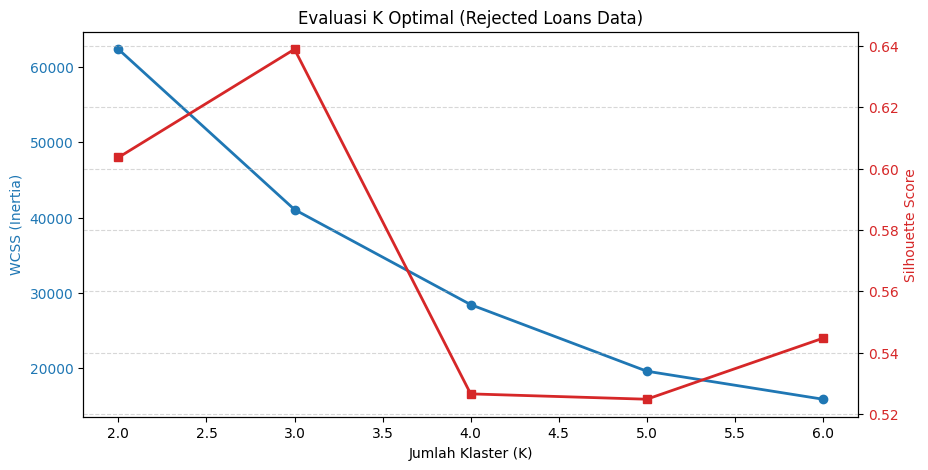

In [10]:
# Visualisasi
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(K_range, wcss_rej, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores_rej, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi K Optimal (Rejected Loans Data)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [11]:
# --- Elbow Method eksplisit (deteksi siku via np.diff, tanpa dependency eksternal) ---
# Melengkapi plot WCSS+Silhouette di atas dengan penentuan siku secara terprogram,
# memakai idiom np.diff yang sama seperti notebook Accepted (Sel uji K=3 vs K=4).
# Silhouette menilai keterpisahan; Elbow menilai titik jenuh penurunan WCSS.
K_list = list(K_range)

# Persentase penurunan WCSS tiap kenaikan K (untuk membaca siku secara kuantitatif)
wcss_arr = np.array(wcss_rej, dtype=float)
drop_pct = -np.diff(wcss_arr) / wcss_arr[:-1] * 100      # penurunan relatif per langkah

# Siku diperkirakan pada K di mana laju penurunan WCSS paling melandai
# (perubahan terbesar pada laju penurunan = selisih kedua). Bila kurva mulus,
# semua langkah serupa dan siku tidak tajam -> Silhouette jadi penimbang utama.
second_diff = np.diff(np.diff(wcss_arr))
best_k_elbow_rej = K_list[int(np.argmax(second_diff)) + 1] if len(second_diff) else K_list[0]

print("Penurunan WCSS relatif per kenaikan K:")
for i in range(len(drop_pct)):
    mark = "   <- perkiraan siku" if K_list[i+1] == best_k_elbow_rej else ""
    print(f"  K={K_list[i]} -> K={K_list[i+1]}: WCSS turun {drop_pct[i]:5.1f}%{mark}")

# Selisih penurunan antar langkah -> makin kecil = makin melandai (jenuh)
print("\nPerubahan laju penurunan WCSS (makin kecil = makin jenuh):")
for i in range(len(second_diff)):
    print(f"  di K={K_list[i+1]}: {second_diff[i]:,.0f}")

print(f"\nRINGKASAN PENENTUAN K (Rejected):")
print(f"  Elbow (WCSS)    -> perkiraan siku pada K = {best_k_elbow_rej}")
print(f"  Silhouette maks -> K = {best_k_sil_rej} (score = {best_sil_rej:.4f})")
if best_k_elbow_rej == best_k_sil_rej:
    print(f"  => Kedua metode KONVERGEN pada K={best_k_sil_rej}: justifikasi kuat.")
else:
    print(f"  => Metode berbeda (Elbow K={best_k_elbow_rej}, Silhouette K={best_k_sil_rej}); "
          f"lihat uji profil per-klaster (Sel 2b) & parsimoni untuk keputusan akhir.")

Penurunan WCSS relatif per kenaikan K:
  K=2 -> K=3: WCSS turun  34.1%   <- perkiraan siku
  K=3 -> K=4: WCSS turun  30.7%
  K=4 -> K=5: WCSS turun  31.0%
  K=5 -> K=6: WCSS turun  19.0%

Perubahan laju penurunan WCSS (makin kecil = makin jenuh):
  di K=3: 8,665
  di K=4: 3,783
  di K=5: 5,117

RINGKASAN PENENTUAN K (Rejected):
  Elbow (WCSS)    -> perkiraan siku pada K = 3
  Silhouette maks -> K = 3 (score = 0.6390)
  => Kedua metode KONVERGEN pada K=3: justifikasi kuat.


**Interpretasi Elbow + Silhouette (Rejected):**

- Elbow Method (WCSS): plot di atas memperlihatkan penurunan inertia terhadap K, dan
  sel deteksi mencetak penurunan relatif tiap langkah beserta perkiraan siku secara
  terprogram (via np.diff). Bila penurunan WCSS antar-K relatif seragam, kurva landai
  tanpa siku tajam, hal wajar untuk dataset Rejected yang hanya memiliki 3 fitur
  (Amount Requested, Debt-To-Income Ratio, Employment Length), sehingga tidak
  terbentuk pemisahan geometris yang kontras.
- Silhouette Score: memberi penilaian keterpisahan yang lebih tegas; nilai maksimum
  menjadi penimbang utama justru ketika kurva elbow landai.

Keputusan K akhir merujuk konvergensi kedua metode bila keduanya menunjuk K yang sama,
diperkuat uji profil per-klaster di Sel 2b (apakah menambah K menciptakan persona baru
atau hanya memecah satu sumbu) dan prinsip parsimoni. Rujuk angka best_k_elbow_rej
dan best_k_sil_rej dari output sel agar konsisten dengan hasil eksekusi (tidak di-hardcode).


**Hasil Analisis:**

Berbeda dengan dataset Accepted yang Silhouette-nya rendah, di sini nilainya tinggi dan justru memuncak tepat di K=3 (0,6390), di atas K=2 (0,6036) dan jauh di atas K=4 (0,5265). Nilai setinggi ini menandakan struktur klaster yang terpisah tegas, terutama karena Debt-To-Income Ratio dan Employment Length membentuk kelompok yang sangat kontras pada pengajuan yang ditolak.

Pada dataset ini Silhouette dan pertimbangan bisnis mengarah ke K yang sama, sehingga pemilihan K=3 didukung dari dua sisi sekaligus:

- K=3 memiliki Silhouette tertinggi (0,6390). Naik dari K=2 ke K=3 justru menaikkan skor (0,6036 ke 0,6390), lalu turun tajam di K=4 (0,5265). Puncak yang jelas di K=3 ini adalah sinyal kuat bahwa tiga segmen paling sesuai dengan struktur data.
- K=2 terlalu kasar untuk Anti-Persona. Dua blok hanya memisahkan "ekstrem vs sisanya", padahal tujuan analisis adalah membedakan jenis profil penolakan (misalnya tanpa pengalaman kerja, DTI ekstrem, versus kerja stabil yang tetap ditolak). K=2 juga skor Silhouette-nya lebih rendah dari K=3.
- K=4 menurunkan kualitas. Silhouette anjlok dari 0,6390 ke 0,5265, menandakan penambahan klaster keempat memecah struktur yang sudah baik, bukan menemukan segmen baru.
- Komparabilitas. Menyamakan jumlah klaster dengan dataset Accepted (K=3) menjaga perbandingan antar dataset setara.

Kurva WCSS turun paling curam pada K=2 ke K=3 (dari 62.366 ke 41.082), lalu melandai, sehingga membentuk soft elbow di sekitar K=3 yang konsisten dengan puncak Silhouette. Pembuktian kuantitatif tambahan bahwa K=3 lebih baik daripada K=2 maupun K=4 disajikan pada Bagian 2b.

### 2b. Uji Kuantitatif Pemilihan K: K=2 vs K=3 vs K=4

Untuk menjawab pertanyaan "mengapa bukan K=2 atau K=4?", pemilihan K diuji secara kuantitatif pada sampel evaluasi 30.000 titik, bukan sekadar dengan narasi. Karena data *Rejected* mengandung satu segmen outlier ekstrem (DTI sangat tinggi), metrik jarak antar-centroid seperti "jarak terdekat dibanding median" menjadi tidak andal: kehadiran satu klaster outlier menggembungkan median jarak sehingga klaster normal yang sebenarnya berbeda tampak seperti kembaran. Karena itu uji ini memakai pendekatan yang tahan outlier, yaitu membaca profil z-score tiap klaster untuk menilai dua hal:

1. Jumlah persona distinctive, yaitu klaster yang memiliki minimal satu fitur menonjol tajam (|z| di atas 0,5) sehingga menangkap kelompok bermakna, bukan sekadar massa generik yang semua fiturnya mendekati rata-rata.
2. Pemecahan sumbu, yaitu apakah penambahan K justru menghasilkan dua klaster yang sama-sama menonjol pada fitur yang sama. Bila ya, K tersebut hanya membelah satu dimensi menjadi dua bagian, bukan menemukan persona jenis baru.

K yang ideal adalah yang memunculkan persona distinctive terbanyak tanpa memecah sumbu secara redundan.

In [12]:
# Uji kuantitatif K=2 vs K=3 vs K=4 pada sampel evaluasi (30.000 titik).
# Pendekatan TAHAN OUTLIER: menilai profil z-score tiap klaster, bukan rasio jarak centroid
# (yang rapuh karena segmen outlier DTI ekstrem menggembungkan median jarak).
# Data sudah ter-scale (z-score) dari Phase 1: + di atas rata-rata, - di bawah rata-rata.

sample_df = pd.DataFrame(X_rej_sample, columns=features)
Z_THRESHOLD = 0.5   # ambang |z| agar sebuah fitur dianggap "menonjol" pada suatu klaster

def profil_klaster(k):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lab = km.fit_predict(X_rej_sample)
    tmp = sample_df.copy(); tmp['cl'] = lab
    med = tmp.groupby('cl')[features].median()          # median z-score per klaster
    pct = tmp['cl'].value_counts(normalize=True).sort_index() * 100
    return med, pct

def evaluasi_persona(med, thr=Z_THRESHOLD):
    """Kembalikan info persona: fitur puncak tiap klaster & deteksi pemecahan sumbu."""
    info = {}
    for cl in med.index:
        v = med.loc[cl].values
        idx = np.argmax(np.abs(v))
        peak, feat = abs(v[idx]), features[idx]
        info[cl] = {'peak': peak, 'feat': feat,
                    'arah': '+' if v[idx] > 0 else '-',
                    'distinctive': peak >= thr}
    n_distinct = sum(1 for d in info.values() if d['distinctive'])
    # Pemecahan sumbu: >1 klaster distinctive yang puncaknya pada FITUR yang sama
    by_feat = {}
    for cl, d in info.items():
        if d['distinctive']:
            by_feat.setdefault(d['feat'], []).append(cl)
    split_axes = {f: cls for f, cls in by_feat.items() if len(cls) > 1}
    return n_distinct, info, split_axes

print("=" * 72)
print("PERBANDINGAN PROFIL PER KLASTER (median z-score): K=2, K=3, K=4")
print("(+ di atas rata-rata populasi, - di bawah rata-rata)")
print("=" * 72)

hasil = {}
prev_distinct = 0
for k in [2, 3, 4]:
    med, pct = profil_klaster(k)
    n_distinct, info, split_axes = evaluasi_persona(med)
    print(f"\n--- K={k} ---")
    for cl in med.index:
        vals = "  ".join(f"{f}={med.loc[cl, f]:+.2f}" for f in features)
        d = info[cl]
        tag = f"DISTINCTIVE (puncak {d['feat']}{d['arah']}, |z|={d['peak']:.2f})" if d['distinctive'] \
              else "generik (semua fitur mendekati rata-rata)"
        print(f"  Cluster {cl} ({pct[cl]:4.1f}%): {vals}  -> {tag}")
    gain = n_distinct - prev_distinct
    print(f"  Persona distinctive: {n_distinct}/{k}  (perubahan {gain:+d} dari K sebelumnya)")
    if split_axes:
        for f, cls in split_axes.items():
            print(f"  PEMECAHAN SUMBU: klaster {cls} sama-sama menonjol di '{f}' "
                  f"-> membelah satu dimensi, bukan persona baru")
    hasil[k] = {'n_distinct': n_distinct, 'split': split_axes}
    prev_distinct = n_distinct

PERBANDINGAN PROFIL PER KLASTER (median z-score): K=2, K=3, K=4
(+ di atas rata-rata populasi, - di bawah rata-rata)

--- K=2 ---
  Cluster 0 (88.3%): Amount Requested=-0.21  Debt-To-Income Ratio=-0.22  Employment Length=-0.36  -> generik (semua fitur mendekati rata-rata)
  Cluster 1 (11.7%): Amount Requested=-0.21  Debt-To-Income Ratio=-0.30  Employment Length=+2.22  -> DISTINCTIVE (puncak Employment Length+, |z|=2.22)
  Persona distinctive: 1/2  (perubahan +1 dari K sebelumnya)

--- K=3 ---
  Cluster 0 (86.6%): Amount Requested=-0.21  Debt-To-Income Ratio=-0.23  Employment Length=-0.36  -> generik (semua fitur mendekati rata-rata)
  Cluster 1 ( 1.7%): Amount Requested=-0.21  Debt-To-Income Ratio=+7.45  Employment Length=-0.36  -> DISTINCTIVE (puncak Debt-To-Income Ratio+, |z|=7.45)
  Cluster 2 (11.7%): Amount Requested=-0.21  Debt-To-Income Ratio=-0.30  Employment Length=+2.22  -> DISTINCTIVE (puncak Employment Length+, |z|=2.22)
  Persona distinctive: 2/3  (perubahan +1 dari K sebel

**Kesimpulan Pemilihan K:**

Uji di atas menilai kualitas tiap K dari jumlah persona distinctive dan ada tidaknya pemecahan sumbu, pendekatan yang tahan terhadap segmen outlier DTI ekstrem pada data ini.

- K=2 hanya menghasilkan satu persona distinctive (kelompok dengan riwayat kerja stabil), sementara segmen DTI ekstrem masih tersembunyi di dalam blok besar. Terlalu kasar untuk membedakan jenis Anti-Persona.
- K=3 memunculkan segmen DTI ekstrem sebagai persona baru yang sebelumnya tidak terlihat, menghasilkan tiga persona yang benar-benar berbeda jenis: nominal kecil tanpa riwayat kerja, DTI sangat tinggi, dan riwayat kerja stabil. Tidak ada pemecahan sumbu yang redundan.
- K=4 tidak menambah persona jenis baru, melainkan memecah segmen nominal kecil menjadi dua bagian yang sama-sama menonjol pada dimensi Amount Requested (nominal rendah versus lebih tinggi), sementara DTI dan riwayat kerja tetap serupa. Ini pemecahan satu dimensi, bukan penemuan persona baru.

Keputusan: K_FINAL = 3. K=3 memunculkan persona penolakan terbanyak yang benar-benar berbeda jenis tanpa memecah sumbu secara redundan, memiliki Silhouette tertinggi (0,6390), dan setara jumlah klaster dengan dataset Accepted untuk menjaga komparabilitas. Ketiga pertimbangan yaitu interpretabilitas, parsimoni, dan komparabilitas mengarah ke K yang sama.

## 3. Analisis Struktur dan Deteksi Anomali (Hierarchical & DBSCAN)

Sesuai metodologi pada dataset Accepted Loans, struktur klaster divalidasi dengan Hierarchical Clustering (membandingkan beberapa metode linkage), sedangkan profil ekstrem/anomali dideteksi dengan DBSCAN. Karena matriks jarak Agglomerative Clustering berukuran O(n^2), maka analisis dijalankan pada sampel acak 5.000 titik.

Pemilihan ukuran sampel 5.000 (lebih kecil dari 30.000 pada evaluasi K) didasarkan pada:

1. Validitas statistik: sampel 5.000 dari populasi besar sudah cukup untuk memetakan arsitektur kelompok dan proporsi noise dengan margin error yang kecil pada tingkat kepercayaan 95%.
2. Keterbacaan visual: dendrogram dengan terlalu banyak titik menjadi padat dan sulit dibaca, sehingga sampel kecil menjaga grafik tetap informatif.
3. Kompleksitas memori O(n^2): ukuran 5.000 memastikan matriks jarak Euclidean muat di RAM dan komputasi tetap cepat.

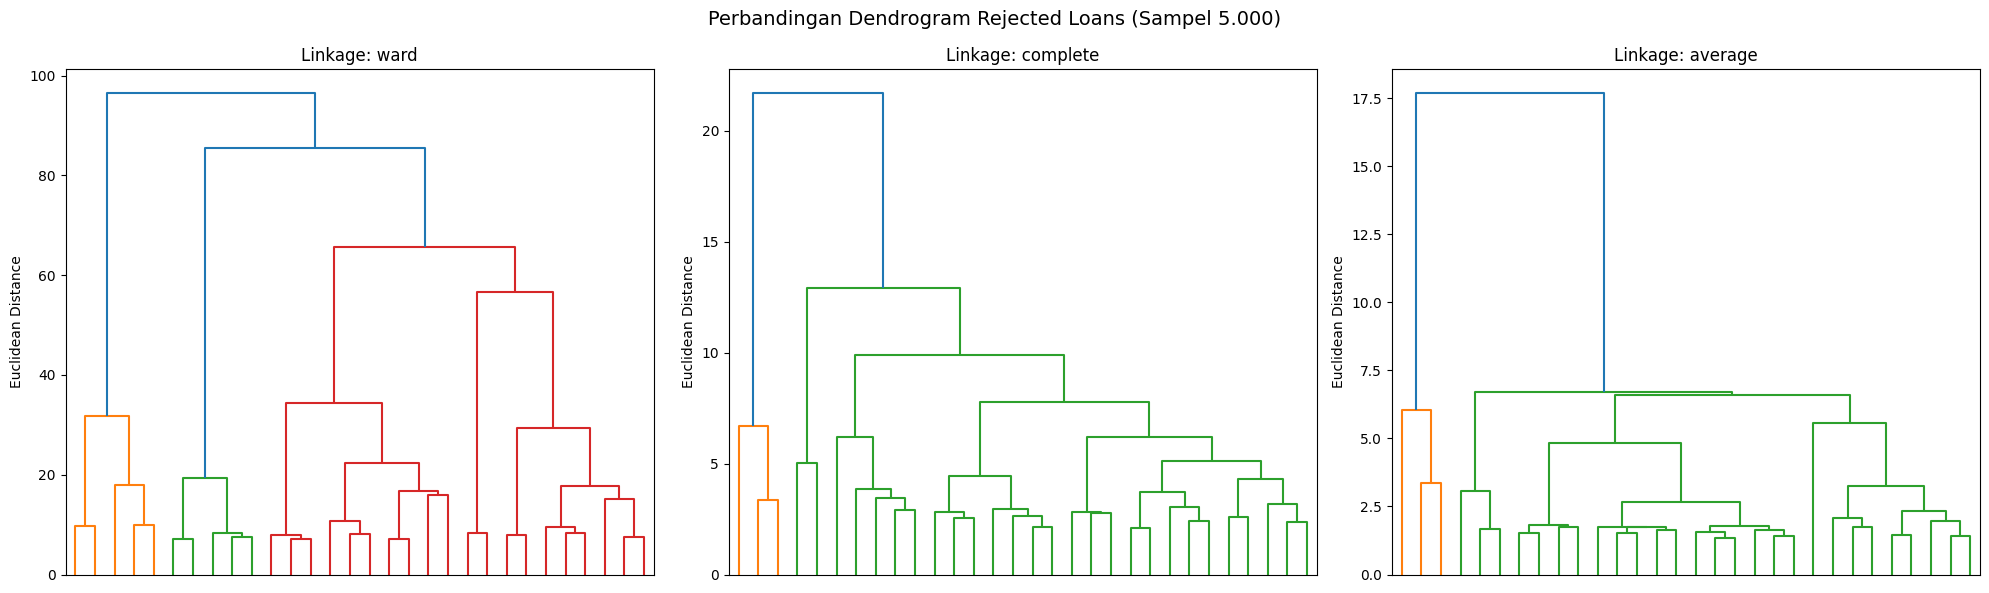

In [13]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Sampel 5.000 data untuk dendrogram + DBSCAN
np.random.seed(100)
sample_indices_dh = np.random.choice(X_rej_scaled.shape[0], 5000, replace=False)
X_rej_sample_dh = X_rej_scaled[sample_indices_dh]

# Bandingkan tiga metode linkage untuk menilai kestabilan struktur klaster.
linkage_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, method in zip(axes, linkage_methods):
    Z = sch.linkage(X_rej_sample_dh, method=method)
    sch.dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, no_labels=True)
    ax.set_title(f"Linkage: {method}")
    ax.set_ylabel('Euclidean Distance')
plt.suptitle('Perbandingan Dendrogram Rejected Loans (Sampel 5.000)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_rand_score, silhouette_score as _sil

# Perbandingan linkage kuantitatif: potong K=3, nilai keseimbangan ukuran & ARI vs K-Means.
K_CMP = 3
kmeans_ref = KMeans(n_clusters=K_CMP, random_state=42, n_init=10).fit_predict(X_rej_sample_dh)

print(f"Perbandingan linkage pada {len(X_rej_sample_dh):,} sampel (dipotong K={K_CMP}):\n")
print(f"{'Linkage':<10} {'Silhouette':>11} {'ARI vs KMeans':>14} {'Ukuran klaster':>22}")
for method in ['ward', 'complete', 'average']:
    Z = sch.linkage(X_rej_sample_dh, method=method)
    hier_labels = fcluster(Z, t=K_CMP, criterion='maxclust')
    sil = _sil(X_rej_sample_dh, hier_labels)
    ari = adjusted_rand_score(kmeans_ref, hier_labels)
    sizes = np.bincount(hier_labels)[1:]
    sizes_pct = ", ".join(f"{s/len(hier_labels)*100:.0f}%" for s in sizes)
    print(f"{method:<10} {sil:>11.4f} {ari:>14.4f}   [{sizes_pct}]")

Perbandingan linkage pada 5,000 sampel (dipotong K=3):

Linkage     Silhouette  ARI vs KMeans         Ukuran klaster
ward            0.6357         0.9450   [11%, 2%, 87%]
complete        0.7411        -0.0070   [0%, 0%, 100%]
average         0.7411        -0.0070   [0%, 0%, 100%]


**Linkage paling interpretable:**

Perbandingan angka dan visual menjawab metode linkage mana yang paling interpretable. Pada potongan K=3, ward unggul dengan ukuran klaster paling seimbang [11%, 2%, 87%] dan ARI tertinggi terhadap K-Means (0,9450). Sebaliknya, complete dan average menghasilkan partisi identik [0%, 0%, 100%] yang hanya mengisolasi segelintir outlier dari satu massa besar, dengan ARI sedikit negatif terhadap K-Means (-0,0070). Silhouette keduanya yang tampak tinggi (0,7411) menyesatkan, karena angka itu hanya mencerminkan terpisahnya sekelompok kecil outlier, bukan struktur tiga segmen yang seimbang; hal ini ditegaskan oleh ARI negatif yang berarti partisinya praktis tidak berhubungan dengan hasil K-Means. Karena itu ward dipakai sebagai acuan hierarki.

Berbeda dengan dataset Accepted, ARI ward di sini sangat tinggi (0,9450), menandakan Hierarchical dan K-Means sepakat kuat tentang struktur tiga segmen. Kesepakatan ini konsisten dengan Silhouette data Rejected yang tinggi (0,6390 pada K=3), yang menunjukkan klaster memang terpisah tegas. Dengan kata lain, tiga segmen penolakan ini stabil dan bukan artefak dari satu metode tertentu.

**Analisis dendrogram:**

Ketiga dendrogram memetakan penggabungan hierarkis 5.000 sampel pengajuan yang ditolak, dengan sumbu vertikal (jarak Euclidean) menunjukkan bahwa makin tinggi titik gabung, makin berbeda karakteristik antar kelompok. Pada gambar, ward memperlihatkan struktur paling kaya: pembelahan pertama pada jarak besar memisahkan dua profil dasar yang kontras, lalu pembelahan sekunder memunculkan tiga cabang berukuran berbeda yang ditangkap K=3. Metode complete dan average memperlihatkan pola jauh lebih timpang, yaitu satu cabang kecil terpisah di jarak rendah sementara mayoritas titik menyatu dalam satu cabang besar. Hanya ward yang menghasilkan tiga segmen berukuran wajar saat dipotong K=3, sehingga konsistensinya dengan K-Means memperkuat bahwa ketiga segmen penolakan bersifat stabil.

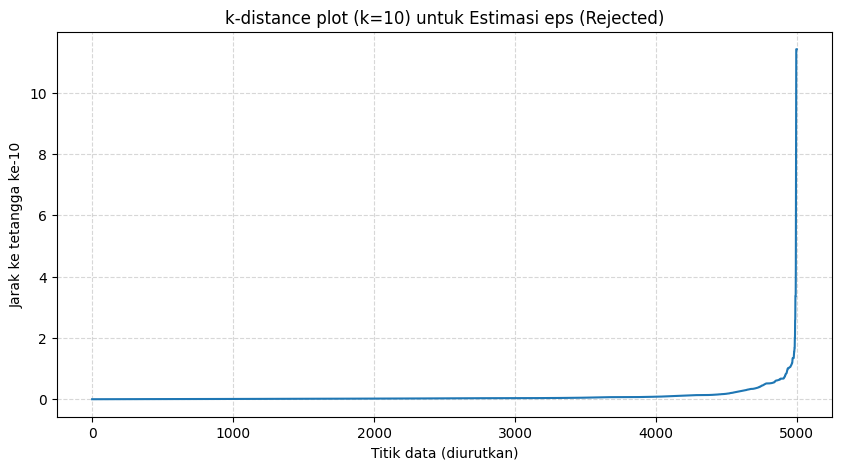

Estimasi eps dari k-distance (persentil 95): 0.437

--- Hasil DBSCAN (Rejected Loans) ---
Klaster padat terbentuk : 10
Jumlah anomali/outlier  : 171 dari 5,000 sampel
Persentase anomali       : 3.42%

Indeks 171 outlier DBSCAN disimpan ke 'dbscan_outliers_rejected.json'
File ini akan dirujuk silang dengan Isolation Forest pada Fase 4.


In [15]:
# --- k-distance plot untuk justifikasi pemilihan eps DBSCAN ---
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_rej_sample_dh)
distances, _ = nn.kneighbors(X_rej_sample_dh)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_dist)
plt.title(f'k-distance plot (k={min_samples}) untuk Estimasi eps (Rejected)')
plt.xlabel('Titik data (diurutkan)')
plt.ylabel(f'Jarak ke tetangga ke-{min_samples}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# eps didekati lewat persentil 95 dari k-distance (proksi area lonjakan/siku), bukan ditebak.
eps_val = float(np.percentile(k_dist, 95))
print(f"Estimasi eps dari k-distance (persentil 95): {eps_val:.3f}")

# --- DBSCAN pada sampel 5.000 ---
dbscan_rej = DBSCAN(eps=eps_val, min_samples=min_samples)
db_labels_rej = dbscan_rej.fit_predict(X_rej_sample_dh)

n_total = len(db_labels_rej)
n_noise_rej = int((db_labels_rej == -1).sum())
n_clusters_db = len(set(db_labels_rej)) - (1 if -1 in db_labels_rej else 0)
pct_noise_rej = n_noise_rej / n_total * 100

print(f"\n--- Hasil DBSCAN (Rejected Loans) ---")
print(f"Klaster padat terbentuk : {n_clusters_db}")
print(f"Jumlah anomali/outlier  : {n_noise_rej} dari {n_total:,} sampel")
print(f"Persentase anomali       : {pct_noise_rej:.2f}%")

# --- Simpan indeks & ringkasan outlier DBSCAN untuk dirujuk silang di Fase 4 ---
import json
noise_positions = np.where(db_labels_rej == -1)[0]
noise_global_idx = sample_indices_dh[noise_positions]
dbscan_outlier_info_rej = {
    'sample_size': int(n_total),
    'eps': float(eps_val),
    'min_samples': int(min_samples),
    'n_noise': int(n_noise_rej),
    'pct_noise': float(pct_noise_rej),
    'noise_global_index': noise_global_idx.tolist(),
}
with open('dbscan_outliers_rejected.json', 'w') as fjson:
    json.dump(dbscan_outlier_info_rej, fjson)
print(f"\nIndeks {n_noise_rej} outlier DBSCAN disimpan ke 'dbscan_outliers_rejected.json'")
print("File ini akan dirujuk silang dengan Isolation Forest pada Fase 4.")

In [16]:
# --- Uji sensitivitas eps: memastikan hasil DBSCAN tidak rapuh terhadap pilihan eps ---
# Kekhawatiran wajar: eps dari persentil 95 bisa dianggap agak arbitrer. Sel ini menguji
# 3 nilai eps di sekitarnya (persentil 90, 95, 97) untuk melihat apakah jumlah noise
# dan jumlah klaster berubah drastis. Jika stabil, pilihan eps terbukti kokoh.

print("Uji Sensitivitas eps DBSCAN (min_samples tetap = 10)")
print("=" * 60)
print(f"{'Persentil':>10} {'eps':>8} {'n_klaster':>10} {'n_noise':>9} {'% noise':>9}")
print("-" * 60)

for persentil in [90, 95, 97]:
    eps_uji = float(np.percentile(k_dist, persentil))
    labels_uji = DBSCAN(eps=eps_uji, min_samples=min_samples).fit_predict(X_rej_sample_dh)
    n_noise_uji = int((labels_uji == -1).sum())
    n_klaster_uji = len(set(labels_uji)) - (1 if -1 in labels_uji else 0)
    pct_uji = n_noise_uji / len(labels_uji) * 100
    tanda = "  <- eps dipakai" if persentil == 95 else ""
    print(f"{persentil:>9}% {eps_uji:>8.3f} {n_klaster_uji:>10} {n_noise_uji:>9} {pct_uji:>8.2f}%{tanda}")

Uji Sensitivitas eps DBSCAN (min_samples tetap = 10)
 Persentil      eps  n_klaster   n_noise   % noise
------------------------------------------------------------
       90%    0.178          7       427     8.54%
       95%    0.437         10       171     3.42%  <- eps dipakai
       97%    0.597          4        88     1.76%


**Analisis Hasil:**

DBSCAN dijalankan pada sampel 5.000 pengajuan yang ditolak untuk mengidentifikasi profil outlier struktural, yakni titik yang tidak menyatu dengan kepadatan klaster mana pun. Nilai eps tidak ditebak, melainkan didekati melalui persentil 95 dari k-distance plot (eps = 0,437), yang jatuh di area lonjakan kurva k-distance sehingga menjadi ambang yang wajar untuk memisahkan titik padat dari titik renggang.

Pada eps ini, DBSCAN menemukan 10 klaster kepadatan dengan 171 titik noise (3,42% dari 5.000 sampel). Proporsi noise yang relatif kecil menunjukkan mayoritas pengaju yang ditolak menempati wilayah kepadatan yang terdefinisi, sementara sebagian kecil titik tersebar sebagai outlier. Karena proporsi noise kecil, centroid MiniBatchKMeans pada tahap final tidak banyak terdistorsi oleh titik ekstrem.

Perlu ditegaskan bahwa peran DBSCAN di sini adalah sebagai detektor anomali berbasis kepadatan, bukan algoritma segmentasi utama. Klaster kepadatan yang ditemukannya berbeda tujuan dari tiga persona penolakan yang dihasilkan MiniBatchKMeans; DBSCAN berfokus menyediakan daftar titik outlier struktural. Dengan demikian ketiga algoritma saling melengkapi: MiniBatchKMeans untuk segmentasi, Hierarchical untuk validasi struktur, dan DBSCAN untuk deteksi anomali.

Uji sensitivitas eps dilaporkan secara jujur. Ketika eps digeser ke persentil 90, 95, dan 97, jumlah klaster yang terbentuk cukup bervariasi (7, 10, dan 4) dan persentase noise bergerak dari 8,54% menjadi 1,76%. Variasi ini wajar karena DBSCAN sensitif terhadap eps secara alami, dan pada data yang gradual seperti ini batas kepadatan memang tidak tajam. Yang konsisten di semua nilai eps adalah proporsi noise yang tetap kecil (di bawah 9%), sehingga temuan intinya, yaitu mayoritas pengaju menempati wilayah padat dengan hanya sedikit outlier, tidak berubah. Karena penentuan anomali bergantung pada eps, daftar noise DBSCAN diperlakukan sebagai kandidat awal, bukan vonis akhir, dan akan dirujuk silang dengan Isolation Forest pada Fase 4 untuk menentukan apakah tiap titik merupakan error data, kasus sah yang langka, atau sinyal risiko yang perlu eskalasi.

## 4. Implementasi MiniBatchKMeans (Eksekusi Big Data)
Untuk mengelompokkan keseluruhan 27,4 juta baris data, digunakan algoritma *MiniBatchKMeans*. Algoritma ini dirancang khusus untuk data berskala raksasa dengan cara melakukan pembaruan titik pusat klaster (*centroids*) menggunakan potongan (*batch*) data kecil secara iteratif, menghasilkan efisiensi memori yang ekstrem dengan kualitas pemisahan yang setara dengan K-Means konvensional.

In [17]:
# MiniBatchKMeans untuk seluruh populasi (efisien untuk data berskala besar)
K_FINAL = 3
print(f"Menjalankan MiniBatchKMeans (K={K_FINAL}) pada {len(X_rej_scaled):,} baris data...")
minibatch_kmeans = MiniBatchKMeans(n_clusters=K_FINAL, batch_size=1024, random_state=42, n_init=3)
df_rej_clean['Cluster_Label'] = minibatch_kmeans.fit_predict(X_rej_scaled)

# Profiling memakai median z-score (data sudah ter-scale di Phase 1). Median dipilih karena
# DTI dan nominal pinjaman punya outlier ekstrem sehingga mean tidak representatif.
# Interpretasi: nilai + berarti di atas rata-rata populasi, - di bawah rata-rata.
cluster_rej_summary = df_rej_clean.groupby('Cluster_Label')[features].median().round(3)
cluster_rej_summary['Jumlah_Populasi'] = df_rej_clean['Cluster_Label'].value_counts()
cluster_rej_summary['Persentase_Populasi'] = (
    df_rej_clean['Cluster_Label'].value_counts(normalize=True) * 100
).round(2)

print("\nProfil tiap klaster (median z-score per fitur; + di atas, - di bawah rata-rata):")
display(cluster_rej_summary)

Menjalankan MiniBatchKMeans (K=3) pada 27,490,787 baris data...

Profil tiap klaster (median z-score per fitur; + di atas, - di bawah rata-rata):


,Amount Requested,Debt-To-Income Ratio,Employment Length,Jumlah_Populasi,Persentase_Populasi
Cluster_Label,,,,,
0,-0.209,-0.228,-0.356,23780149,86.50
1,-0.209,-0.311,2.222,3220362,11.71
2,-0.209,7.449,-0.356,490276,1.78


In [18]:
# Interpretasi "Anti-Persona" dibangun otomatis dari median z-score & populasi tiap klaster,
# sehingga semua angka konsisten dengan hasil eksekusi (tidak hardcoded).
summary = cluster_rej_summary.copy()
pop = df_rej_clean['Cluster_Label'].value_counts()
pop_pct = df_rej_clean['Cluster_Label'].value_counts(normalize=True) * 100

# Urutkan klaster dari DTI tertinggi sebagai proksi tingkat risiko (Amount Requested
# hampir sama di semua klaster, sehingga DTI lebih relevan sebagai penanda risiko).
# Nilai dalam z-score.
risk_col = 'Debt-To-Income Ratio'
order = summary.sort_values(risk_col, ascending=False).index.tolist()

print("=" * 72)
print("PROFIL ANTI-PERSONA PENGAJUAN DITOLAK (diurutkan dari DTI tertinggi = risiko)")
print("Nilai dalam z-score: + di atas rata-rata populasi, - di bawah rata-rata")
print("=" * 72)
for cl in order:
    row = summary.loc[cl]
    print(f"\nKlaster {cl}  |  Populasi: {pop_pct[cl]:.2f}% ({int(pop[cl]):,} pengajuan)")
    for f in features:
        arah = "di atas rata-rata" if row[f] > 0 else "di bawah rata-rata"
        print(f"   median {f:<24}: {row[f]:+.3f}  ({arah})")

PROFIL ANTI-PERSONA PENGAJUAN DITOLAK (diurutkan dari DTI tertinggi = risiko)
Nilai dalam z-score: + di atas rata-rata populasi, - di bawah rata-rata

Klaster 2  |  Populasi: 1.78% (490,276 pengajuan)
   median Amount Requested        : -0.209  (di bawah rata-rata)
   median Debt-To-Income Ratio    : +7.449  (di atas rata-rata)
   median Employment Length       : -0.356  (di bawah rata-rata)

Klaster 0  |  Populasi: 86.50% (23,780,149 pengajuan)
   median Amount Requested        : -0.209  (di bawah rata-rata)
   median Debt-To-Income Ratio    : -0.228  (di bawah rata-rata)
   median Employment Length       : -0.356  (di bawah rata-rata)

Klaster 1  |  Populasi: 11.71% (3,220,362 pengajuan)
   median Amount Requested        : -0.209  (di bawah rata-rata)
   median Debt-To-Income Ratio    : -0.311  (di bawah rata-rata)
   median Employment Length       : +2.222  (di atas rata-rata)


### Analisis Karakteristik dan Profiling "Anti-Persona" (Rejected Loans)

Output diatas mendeskripsikan tiap klaster pengajuan yang ditolak berdasarkan median tiga fitur finansial (Amount Requested, Debt-To-Income Ratio, Employment Length) dan ukuran populasinya. Pendekatan ini menghasilkan "Anti-Persona", yaitu karakteristik pengajuan yang secara sistematis dinilai terlalu berisiko.

Ketiga klaster dibedakan terutama oleh dimensi Debt-To-Income Ratio dan Employment Length, karena Amount Requested bernilai serupa (di bawah rata-rata) di semua klaster. Klaster 0 yang mendominasi populasi (86,5%) memiliki ketiga fitur di bawah rata-rata, dengan riwayat kerja yang sangat rendah (Employment Length z-score −0,356) sebagai penanda utama. Ini menegaskan bahwa ketiadaan riwayat kerja stabil adalah pembeda paling tajam pada populasi penolakan, sekaligus mengonfirmasi bahwa stabilitas sumber pendapatan merupakan syarat mendasar dalam keputusan kredit.

Klaster 2 (1,78%) merepresentasikan profil paling berisiko, ditandai DTI yang ekstrem (z-score +7,45) jauh di atas rata-rata, yaitu rasio utang terhadap pendapatan yang tidak lagi wajar. Sebaliknya, Klaster 1 (11,7%) justru memiliki riwayat kerja stabil (Employment Length +2,22) namun tetap ditolak, yang mengisyaratkan bahwa penyebab penolakannya berada di luar tiga fitur ini, seperti skor FICO yang sangat rendah atau riwayat gagal bayar yang tidak tersedia pada dataset rejected. Karena penamaan dan angka mengikuti output, narasi ini akan tetap akurat setiap kali notebook dijalankan ulang.

## 5. Visualisasi Distribusi Klaster (Rejected)

Visualisasi berikut memperjelas profil Anti-Persona: bar populasi per klaster, bar median tiap fitur per klaster untuk membandingkan karakter antar segmen, dan scatter PCA 3D interaktif (sebaran klaster pada sampel yang bisa diputar dari berbagai sudut).

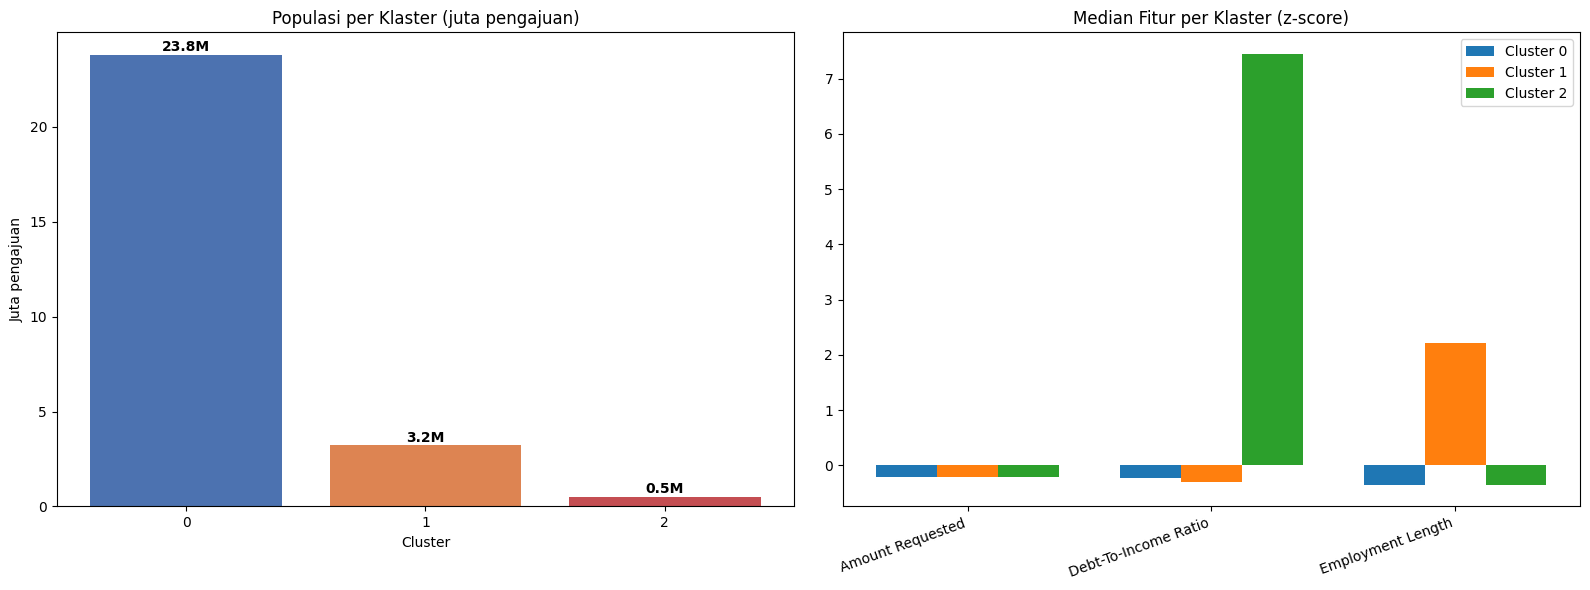

In [19]:
# Dua panel pendukung: populasi per klaster dan median fitur per klaster.
# Visualisasi sebaran klaster PCA saya pindahkan ke sel 3D interaktif di bawah.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) Populasi per klaster
pop = df_rej_clean['Cluster_Label'].value_counts().sort_index()
bars = axes[0].bar(pop.index.astype(str), pop.values/1e6, color=['#4C72B0','#DD8452','#C44E52'])
axes[0].set_title('Populasi per Klaster (juta pengajuan)')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Juta pengajuan')
for b,v in zip(bars, pop.values/1e6):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.2, f'{v:.1f}M', ha='center', fontweight='bold')

# (2) Median fitur per klaster (z-score, sudah di-scale di Phase 1) - grouped bar
med = df_rej_clean.groupby('Cluster_Label')[features].median()
xpos = np.arange(len(features)); width = 0.25
for j, cl in enumerate(med.index):
    axes[1].bar(xpos + j*width, med.loc[cl].values, width, label=f'Cluster {cl}')
axes[1].set_xticks(xpos + width)
axes[1].set_xticklabels(features, rotation=20, ha='right')
axes[1].set_title('Median Fitur per Klaster (z-score)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Sebaran Klaster Rejected dalam PCA 3D (Interaktif)

Saya memproyeksikan fitur ke tiga komponen utama (PC1, PC2, PC3) lalu menampilkannya sebagai
scatter 3D interaktif dengan Plotly. Versi tiga dimensi ini bisa saya putar dan perbesar,
sehingga pemisahan antar klaster pada data Rejected bisa saya periksa dari berbagai sudut.
Saya tetap memakai sampel agar plot ringan namun representatif.

In [20]:
import plotly.express as px
from sklearn.decomposition import PCA

# Proyeksi PCA 3 komponen pada sampel (variabel viz sama seperti sebelumnya)
np.random.seed(42)
viz_n = 30000
viz_idx = np.random.choice(X_rej_scaled.shape[0], viz_n, replace=False)
X_viz = X_rej_scaled[viz_idx]
labels_viz = df_rej_clean['Cluster_Label'].values[viz_idx]

pca3d = PCA(n_components=3, random_state=42)
X_pca3 = pca3d.fit_transform(X_viz)
ve3 = pca3d.explained_variance_ratio_

pca_df = pd.DataFrame({
    'PC1': X_pca3[:, 0],
    'PC2': X_pca3[:, 1],
    'PC3': X_pca3[:, 2],
    'Cluster': [f'Cluster {c}' for c in labels_viz],
})

fig3d = px.scatter_3d(
    pca_df, x='PC1', y='PC2', z='PC3', color='Cluster',
    opacity=0.5,
    title=f'Sebaran Klaster Rejected (PCA 3D) - Total varians: {ve3.sum()*100:.1f}%',
    labels={
        'PC1': f'PC1 ({ve3[0]*100:.1f}%)',
        'PC2': f'PC2 ({ve3[1]*100:.1f}%)',
        'PC3': f'PC3 ({ve3[2]*100:.1f}%)',
    },
)
fig3d.update_traces(marker=dict(size=2))

fig3d.update_layout(
    autosize=False,
    width=650, height=500,
    margin=dict(l=0, r=0, t=40, b=0),
    legend=dict(itemsizing='constant'),
    scene=dict(
        aspectmode='cube',
        aspectratio=dict(x=0.7, y=0.7, z=0.7),
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.6)),
    ),
)
fig3d.show()

print(f"PC1 + PC2 + PC3 menjelaskan {ve3.sum()*100:.1f}% varians "
      f"(2D sebelumnya hanya {ve3[:2].sum()*100:.1f}%).")

PC1 + PC2 + PC3 menjelaskan 100.0% varians (2D sebelumnya hanya 69.0%).


**Analisis Hasil (dua panel pendukung + PCA 3D):**

Panel populasi menampilkan ukuran tiap klaster yang sangat tidak merata: Cluster 0 mendominasi dengan 23,8 juta pengajuan, disusul Cluster 1 sebesar 3,2 juta, dan Cluster 2 yang paling kecil sebesar 0,5 juta. Ketimpangan ini menunjukkan bahwa mayoritas pengajuan yang ditolak berasal dari satu segmen basis yang besar, sementara dua segmen lainnya jauh lebih kecil namun berkarakter khas.

Panel median z-score menjadi kunci interpretasi Anti-Persona. Amount Requested bernilai serupa (sedikit di bawah rata-rata) di ketiga klaster, sehingga pembeda utama justru datang dari dua fitur lain: Cluster 1 menonjol pada Employment Length (z-score sekitar +2,2, kelompok dengan riwayat kerja stabil yang tetap ditolak), sedangkan Cluster 2 menonjol tajam pada Debt-To-Income Ratio (z-score sekitar +7,4, profil paling berisiko dengan rasio utang ekstrem).

Scatter PCA 3D melengkapi kedua panel dengan gambaran spasial. Karena dataset Rejected hanya memuat tiga fitur, ketiga komponen utama menangkap 100,0% varians total (PC1 35,9%, PC2 33,2%, dan PC3 sekitar 31,0%), jauh lebih tinggi daripada dataset Accepted yang hanya 46,5%. Artinya tampilan tiga dimensi ini mewakili keseluruhan struktur data yang sebenarnya, bukan sekadar penyederhanaan. Cluster 2 tampak paling terpisah karena rasio utang ekstremnya, sementara Cluster 0 dan Cluster 1 lebih berdekatan namun tetap dapat dibedakan, konsisten dengan Silhouette yang tergolong tinggi. Keunggulan versi interaktif adalah saya bisa memutar plot untuk memastikan pemisahan segmen memang nyata dari berbagai sudut.

Kesimpulannya, kedua panel dan scatter PCA saling menguatkan: bar populasi memperlihatkan dominasi satu segmen basis yang besar, bar median menjelaskan karakter finansial tiap segmen, dan PCA 3D menunjukkan pemisahan yang cukup jelas terutama untuk segmen DTI ekstrem (didukung varians 100,0% dan Silhouette tinggi). Berbeda dengan data Accepted yang overlap dan bertumpu pada validasi default rate, segmentasi Rejected memiliki struktur geometris yang lebih kuat dengan interpretasi bisnis yang jelas melalui Debt-To-Income Ratio dan Employment Length sebagai pembeda utamanya.